<a href="https://colab.research.google.com/github/anikmandal96/Advertising/blob/main/Neurootix_Advertising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip -q install opendatasets
import opendatasets as od
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
dataset_url = "https://www.kaggle.com/datasets/bumba5341/advertisingcsv"

od.download(dataset_url)

print("Dataset downloaded successfully!")

Skipping, found downloaded files in "./advertisingcsv" (use force=True to force download)
Dataset downloaded successfully!


In [17]:
import os

os.listdir('/content/advertisingcsv')

['Advertising.csv']

In [18]:
df = pd.read_csv('/content/advertisingcsv/Advertising.csv')

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [19]:
df = df.drop('Unnamed: 0', axis=1)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [21]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [22]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


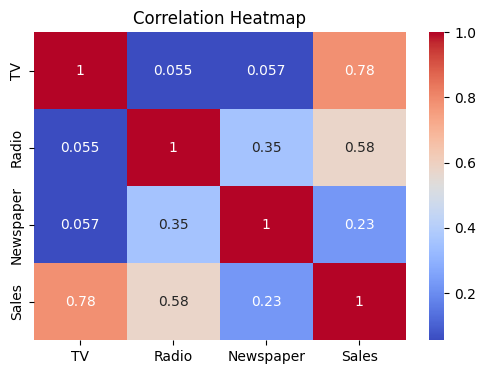

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

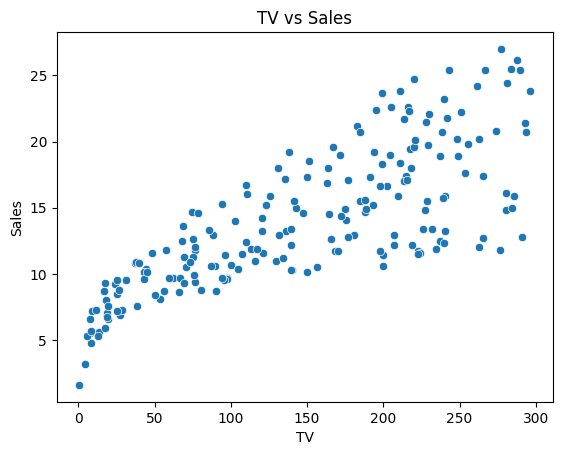

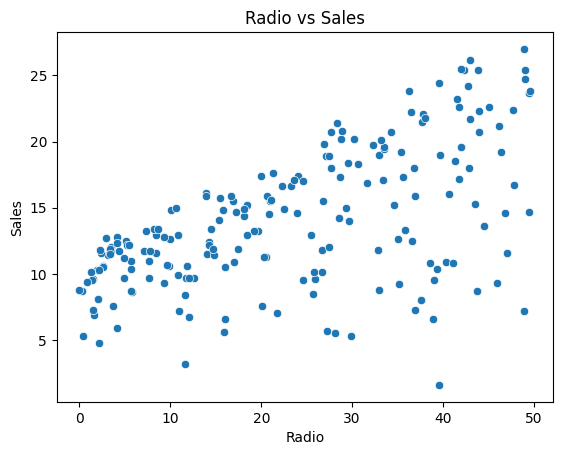

In [38]:
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV vs Sales')
plt.show()
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Radio vs Sales')
plt.show()


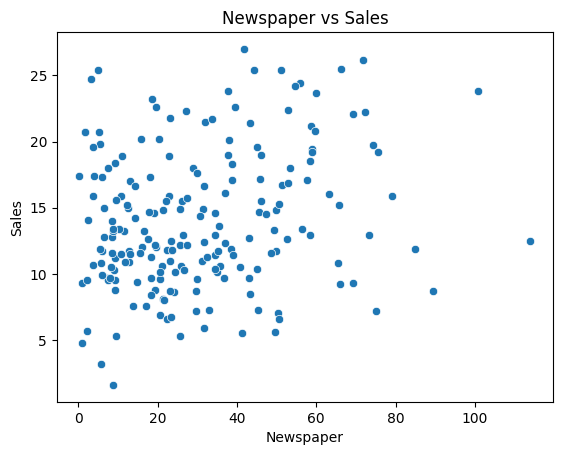

In [39]:
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title('Newspaper vs Sales')
plt.show()

In [40]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print(X.head())
print(y.head())

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [42]:
model = LinearRegression()

model.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


In [43]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [44]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


In [45]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE:', round(mae, 2))
print('MSE:', round(mse, 2))
print('R2 Score:', round(r2, 3))

MAE: 1.46
MSE: 3.17
R2 Score: 0.899


In [53]:
new_campaign = [[250, 40, 20]]

future_sales = model.predict(new_campaign)

print('Predicted Future Sales:', round(future_sales[0], 2))
base = [[200, 30, 20]]
base_sales = model.predict(base)[0]

print('Base Sales:', round(base_sales, 2))

tv_up = [[240, 30, 20]]
tv_sales = model.predict(tv_up)[0]

print('After TV +20%:', round(tv_sales, 2))
print('Increase:', round(tv_sales - base_sales, 2))

radio_up = [[200, 36, 20]]
radio_sales = model.predict(radio_up)[0]

print('After Radio +20%:', round(radio_sales, 2))
print('Increase:', round(radio_sales - base_sales, 2))


news_up = [[200, 30, 24]]
news_sales = model.predict(news_up)[0]

print('After Newspaper +20%:', round(news_sales, 2))
print('Increase:', round(news_sales - base_sales, 2))

Predicted Future Sales: 21.78
Base Sales: 17.66
After TV +20%: 19.45
Increase: 1.79
After Radio +20%: 18.79
Increase: 1.14
After Newspaper +20%: 17.67
Increase: 0.01


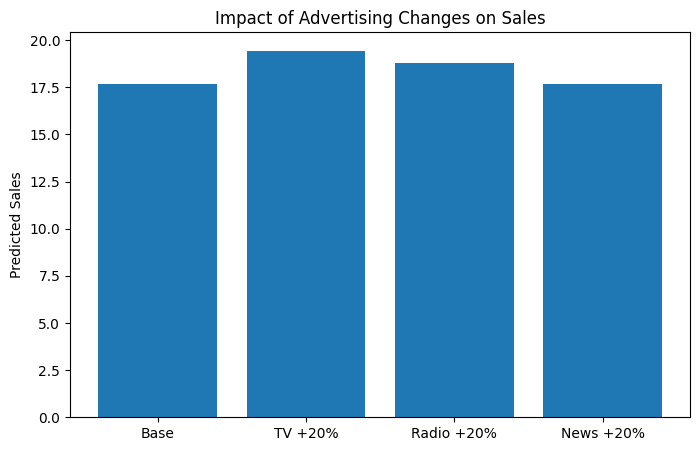

In [54]:
channels = ['Base', 'TV +20%', 'Radio +20%', 'News +20%']
sales = [base_sales, tv_sales, radio_sales, news_sales]

plt.figure(figsize=(8,5))
plt.bar(channels, sales)
plt.ylabel('Predicted Sales')
plt.title('Impact of Advertising Changes on Sales')
plt.show()